In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## baseline spec for classifier

In [2]:
df4 = pd.read_pickle('../data/df4.pkl')

In [3]:
df4.head()

,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,JRNY_ID_NUM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,...,final_full_journey_seq,final_orig_journey_station,final_dest_journey_station,short_round_trip_flag,round_trip_reason,final_termination_flag_spatial,final_termination_reason_spatial,final_termination_flag_spatial_nodist,final_termination_reason_spatial_nodist,final_journey_seq
0,45.0,100006223599,3968.0,2025-02-12,2025-02-12 06:49:58,2025-02-12,2025-02-12 07:00:33,110715426253,4009.0,0.0,...,0,Blk 172,Boon Keng,False,different_origin_destination,False,candidate_transfer,False,candidate_transfer,0
1,NaN,100006223599,109.0,2025-02-12,2025-02-12 07:01:53,2025-02-12,2025-02-12 07:10:18,110713956734,106.0,0.5,...,0,Blk 172,Boon Keng,False,different_origin_destination,True,return_or_intermediate | exceeds_total_allowance,True,return_or_intermediate | exceeds_total_allowance,0
2,NaN,100006223599,106.0,2025-02-12,2025-02-12 15:21:06,2025-02-12,2025-02-12 15:32:56,110713665019,109.0,0.0,...,1,Boon Keng,Opp Blk 169,False,different_origin_destination,False,candidate_transfer,False,candidate_transfer,1
3,45.0,100006223599,4008.0,2025-02-12,2025-02-12 15:42:15,2025-02-12,2025-02-12 15:53:18,110714355046,3967.0,0.0,...,1,Boon Keng,Opp Blk 169,False,different_origin_destination,True,last_stage | null_time_gap,True,last_stage | null_time_gap,1
4,382.0,130013244516,6927.0,2025-02-12,2025-02-12 08:45:07,2025-02-12,2025-02-12 08:59:01,110713628234,5953.0,0.0,...,0,Blk 322 CP,NaN,False,null_origin_or_destination,False,candidate_transfer,False,candidate_transfer,0


In [5]:
print(df4.columns.tolist())

['BUS_SVC_NUM', 'CRD_NUM', 'DEST_LOC_ID_NUM', 'ENTRY_DT', 'ENTRY_TM', 'EXIT_DT', 'EXIT_TM', 'JRNY_ID_NUM', 'ORIG_LOC_ID_NUM', 'RIDE_DISC_AMT', 'RIDE_DIST_KM_CNT', 'RIDE_FARE_AMT', 'RIDE_ID_NUM', 'RIDE_MIN_CNT', 'PATRON_CATG_ID_NUM', 'TRNSPT_MODE_CD', 'DEST_STATION_NAME', 'DEST_MRK_ID_NUM', 'DEST_LATITUDE', 'DEST_LONGITUDE', 'DEST_Travel_Type', 'ORIG_STATION_NAME', 'ORIG_MRK_ID_NUM', 'ORIG_LATITUDE', 'ORIG_LONGITUDE', 'ORIG_Travel_Type', 'next_orig_lat', 'next_orig_lon', 'next_orig_station', 'walk_distance', 'PATRON_CATG_DESC_TXT', 'walking_speed_ms', 'next_ENTRY_TM', 'next_ORIG_LOC_ID_NUM', 'next_BUS_SVC_NUM', 'next_TRNSPT_MODE_CD', 'is_last_stage', 'missing_info', 'same_bus_service', 'same_station_consecutive', 'return_or_intermediate', 'journey_termination_flag', 'journey_termination_reason', 'full_journey_seq', 'orig_journey_station', 'entry_journey_tm', 'dest_journey_station', 'exit_journey_tm', 'next_orig_journey_location', 'walk_to_next_journey_distance', 'time_gap_mins', 'predic

- We compare each transfer window size against our rule-based classifier, which serves as the ground truth proxy for what constitutes a legitimate journey
- The comparison is done at the ride-pair level — each row represents a consecutive pair of rides by the same commuter
- Wrongly split: classifier says the pair is a transfer (same journey), but the window says the gap is too long and breaks them apart → commuter gets overcharged
- Wrongly merged: classifier says the pair is a new journey, but the window links them as a transfer → commuter incorrectly receives a transfer fare discount
- We vary the bus transfer window from 20 to 55 minutes in 5-minute increments, while holding train-to-train transfers fixed at 15 minutes
- For each window size, wrongly split and wrongly merged rates are computed separately for Adult, Student, and Senior Citizen
- As the window increases, wrongly split decreases (window becomes more permissive) and wrongly merged increases (window starts linking rides that should be separate)
- The goal is to identify the window size that best balances these two types of misclassification across patron groups

In [6]:
# filter once upfront — only valid ride pairs
df_pairs = df4[
    (df4['is_last_stage'] == False) &       # must have a next ride
    (df4['time_gap_mins'].notna())           # window needs a time gap to evaluate
].copy()

# reconstruct mode_pair from transport mode codes (1=bus, 2=train)
df_pairs['mode_pair'] = np.select(
    [
        (df_pairs['TRNSPT_MODE_CD'] == 1) & (df_pairs['next_TRNSPT_MODE_CD'] == 1),
        (df_pairs['TRNSPT_MODE_CD'] == 2) & (df_pairs['next_TRNSPT_MODE_CD'] == 1),
        (df_pairs['TRNSPT_MODE_CD'] == 1) & (df_pairs['next_TRNSPT_MODE_CD'] == 2),
        (df_pairs['TRNSPT_MODE_CD'] == 2) & (df_pairs['next_TRNSPT_MODE_CD'] == 2),
    ],
    ['bus_bus', 'train_bus', 'bus_train', 'train_train'],
    default='other'
)

print(f"Total ride pairs: {len(df_pairs):,}")
print(df_pairs['mode_pair'].value_counts())

Total ride pairs: 4,975,441
mode_pair
bus_bus        1805322
train_train    1226656
train_bus       976626
bus_train       966837
Name: count, dtype: int64


In [11]:
# remove rows with unknown patron category
df_pairs = df_pairs[df_pairs['PATRON_CATG_DESC_TXT'].notna()].copy()

In [12]:
# ── Cell 2: window comparison loop ───────────────────────────────────────────

results = []

for w in range(20, 60, 5):

    # assign window per row: train_train fixed at 15, everything else = w
    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    # classifier verdict: False = transfer (same journey)
    classifier_says_transfer = (df_pairs['final_termination_flag_spatial'] == False)

    # window verdict: gap <= window = transfer
    window_says_transfer = (df_pairs['time_gap_mins'] <= window)

    # disagreements
    wrongly_split  = classifier_says_transfer & ~window_says_transfer   # classifier=transfer, window=new journey
    wrongly_merged = ~classifier_says_transfer & window_says_transfer   # classifier=new journey, window=transfer

    # overall
    results.append({
        'window_mins':       w,
        'patron':            'Overall',
        'wrongly_split_n':   wrongly_split.sum(),
        'wrongly_merged_n':  wrongly_merged.sum(),
        'wrongly_split_pct':  wrongly_split.mean() * 100,
        'wrongly_merged_pct': wrongly_merged.mean() * 100,
    })

    # by patron category
    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs['PATRON_CATG_DESC_TXT'] == patron   # boolean mask for this patron
        results.append({
            'window_mins':       w,
            'patron':            patron,
            'wrongly_split_n':   wrongly_split[mask].sum(),
            'wrongly_merged_n':  wrongly_merged[mask].sum(),
            'wrongly_split_pct':  wrongly_split[mask].mean() * 100,
            'wrongly_merged_pct': wrongly_merged[mask].mean() * 100,
        })

results_df = pd.DataFrame(results)
print(results_df)

    window_mins          patron  wrongly_split_n  wrongly_merged_n  \
0            20         Overall            38159            440547   
1            20         Student             3531             49303   
2            20           Adult            24662            270681   
3            20  Senior Citizen             9966            120563   
4            25         Overall             7117            484306   
5            25         Student              814             52293   
6            25           Adult             4667            298909   
7            25  Senior Citizen             1636            133104   
8            30         Overall             3576            539880   
9            30         Student              393             56070   
10           30           Adult             2717            333609   
11           30  Senior Citizen              466            150201   
12           35         Overall             3273            589917   
13           35     

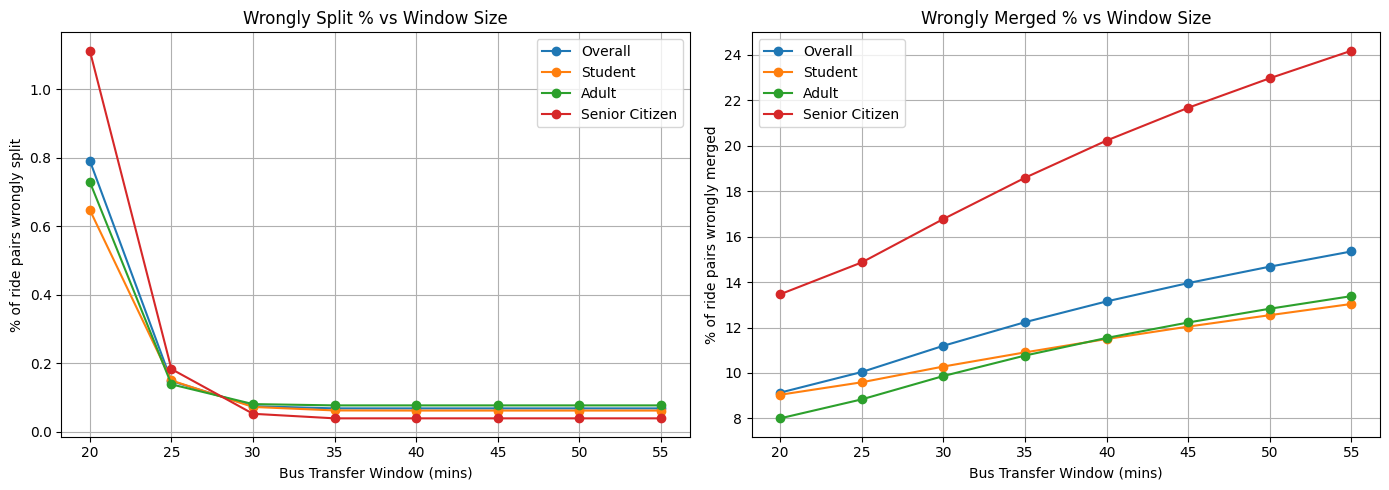

In [13]:
# ── Cell 3: visualise ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for patron in results_df['patron'].unique():
    sub = results_df[results_df['patron'] == patron].sort_values('window_mins')
    axes[0].plot(sub['window_mins'], sub['wrongly_split_pct'],  marker='o', label=patron)
    axes[1].plot(sub['window_mins'], sub['wrongly_merged_pct'], marker='o', label=patron)

axes[0].set_title('Wrongly Split % vs Window Size')
axes[0].set_xlabel('Bus Transfer Window (mins)')
axes[0].set_ylabel('% of ride pairs wrongly split')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Wrongly Merged % vs Window Size')
axes[1].set_xlabel('Bus Transfer Window (mins)')
axes[1].set_ylabel('% of ride pairs wrongly merged')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
# ── Cell 4: store results as df for later use ────────────────────────────────

# classifier verdicts — fixed truth
classifier_says_transfer = (df_pairs['final_termination_flag_spatial'] == False)

baseline_results = []

for w in range(20, 60, 5):

    window = df_pairs['mode_pair'].map(
        lambda x: 15 if x == 'train_train' else w
    )

    window_says_transfer = (df_pairs['time_gap_mins'] <= window)

    wrongly_split  = classifier_says_transfer & ~window_says_transfer
    wrongly_merged = ~classifier_says_transfer & window_says_transfer

    # overall
    baseline_results.append({
        'spec':                     'baseline',
        'window_mins':              w,
        'patron':                   'Overall',
        'classifier_transfer_n':    classifier_says_transfer.sum(),
        'classifier_new_journey_n': (~classifier_says_transfer).sum(),
        'window_transfer_n':        window_says_transfer.sum(),
        'window_new_journey_n':     (~window_says_transfer).sum(),
        'wrongly_split_n':          wrongly_split.sum(),
        'wrongly_merged_n':         wrongly_merged.sum(),
        'wrongly_split_pct':        wrongly_split.mean() * 100,
        'wrongly_merged_pct':       wrongly_merged.mean() * 100,
    })

    # by patron
    for patron in df_pairs['PATRON_CATG_DESC_TXT'].unique():
        mask = df_pairs['PATRON_CATG_DESC_TXT'] == patron
        baseline_results.append({
            'spec':                     'baseline',
            'window_mins':              w,
            'patron':                   patron,
            'classifier_transfer_n':    classifier_says_transfer[mask].sum(),
            'classifier_new_journey_n': (~classifier_says_transfer[mask]).sum(),
            'window_transfer_n':        window_says_transfer[mask].sum(),
            'window_new_journey_n':     (~window_says_transfer[mask]).sum(),
            'wrongly_split_n':          wrongly_split[mask].sum(),
            'wrongly_merged_n':         wrongly_merged[mask].sum(),
            'wrongly_split_pct':        wrongly_split[mask].mean() * 100,
            'wrongly_merged_pct':       wrongly_merged[mask].mean() * 100,
        })

results_baseline_df = pd.DataFrame(baseline_results)
print(results_baseline_df.to_string())

        spec  window_mins          patron  classifier_transfer_n  classifier_new_journey_n  window_transfer_n  window_new_journey_n  wrongly_split_n  wrongly_merged_n  wrongly_split_pct  wrongly_merged_pct
0   baseline           20         Overall                1718541                   3103157            2120929               2700769            38159            440547           0.791402            9.136761
1   baseline           20         Student                 201707                    343470             247479                297698             3531             49303           0.647680            9.043485
2   baseline           20           Adult                1233174                   2147808            1479193               1901789            24662            270681           0.729433            8.005988
3   baseline           20  Senior Citizen                 283660                    611879             394257                501282             9966            120563          

## lenient spec for classifier

# Ignore below pls

### 45 min transfer window for bus-train, bus-bus rides. 15 min for train-train rides

In [ ]:
'''# define transfer window based on mode combination
df4['transfer_window_mins'] = np.where(
    (df4['TRNSPT_MODE_CD'] == 2) & (df4['next_TRNSPT_MODE_CD'] == 2),
    15,   # train to train
    45    # everything else
)

# flag: exceeds transfer window → new journey
df4['window_flag'] = (
    df4['time_gap_mins'] > df4['transfer_window_mins']
) | df4['time_gap_mins'].isna()'''

In [ ]:
'''# recompute journey sequence using window only
df4['window_journey_seq'] = (
    df4.groupby('CRD_NUM')['window_flag']
       .shift(fill_value=False)
       .groupby(df4['CRD_NUM'])
       .cumsum()
)'''

In [ ]:
'''# stage counts per journey
window_stage_counts = (
    df4.groupby(['CRD_NUM', 'window_journey_seq', 'PATRON_CATG_DESC_TXT'])
       .size()
       .reset_index(name='stage_count')
)

window_stage_counts['is_single_stage'] = window_stage_counts['stage_count'] == 1

window_summary = (
    window_stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                       .size()
                       .unstack(fill_value=0)
                       .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
)
window_summary['total_journeys'] = window_summary['single_stage_journeys'] + window_summary['multi_stage_journeys']
window_summary['multi_stage_%'] = (window_summary['multi_stage_journeys'] / window_summary['total_journeys'] * 100).round(2)

print(window_summary)'''

is_single_stage       multi_stage_journeys  single_stage_journeys  \
PATRON_CATG_DESC_TXT                                                
Adult                              1323381                2372249   
Senior Citizen                      351407                 436554   
Student                             217114                 351012   

is_single_stage       total_journeys  multi_stage_%  
PATRON_CATG_DESC_TXT                                 
Adult                        3695630          35.81  
Senior Citizen                787961          44.60  
Student                       568126          38.22  


#### toggling between different transfer windows for bus-train and bus-bus. (keep train-train constant at 15mins since not in the qn)

In [ ]:
'''
def compute_window_summary(df, bus_window, train_window=15):
    flag = (
        df['time_gap_mins'] > df['TRNSPT_MODE_CD'].map(
            lambda x: train_window if x == 2 else bus_window
        )
    ) | df['time_gap_mins'].isna()

    # assign flag as temp column to use in groupby
    df = df.assign(window_flag=flag)

    journey_seq = (
        df.groupby('CRD_NUM')['window_flag']
          .shift(fill_value=False)
          .groupby(df['CRD_NUM'])
          .cumsum()
    )

    stage_counts = (
        df.assign(window_journey_seq=journey_seq)
          .groupby(['CRD_NUM', 'window_journey_seq', 'PATRON_CATG_DESC_TXT'])
          .size()
          .reset_index(name='stage_count')
    )

    stage_counts['is_single_stage'] = stage_counts['stage_count'] == 1

    summ = (
        stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                    .size()
                    .unstack(fill_value=0)
                    .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
    )
    summ['total_journeys'] = summ['single_stage_journeys'] + summ['multi_stage_journeys']
    summ['multi_stage_%'] = (summ['multi_stage_journeys'] / summ['total_journeys'] * 100).round(2)
    return summ
    '''

In [ ]:
'''# WARNING: will take 9mins to run
# loop over range of bus windows
results = {}
for w in range(30, 65, 5):
    results[w] = compute_window_summary(df4, bus_window=w)
    print(f"Done: {w} min")'''

Done: 30 min
Done: 35 min
Done: 40 min
Done: 45 min
Done: 50 min
Done: 55 min
Done: 60 min


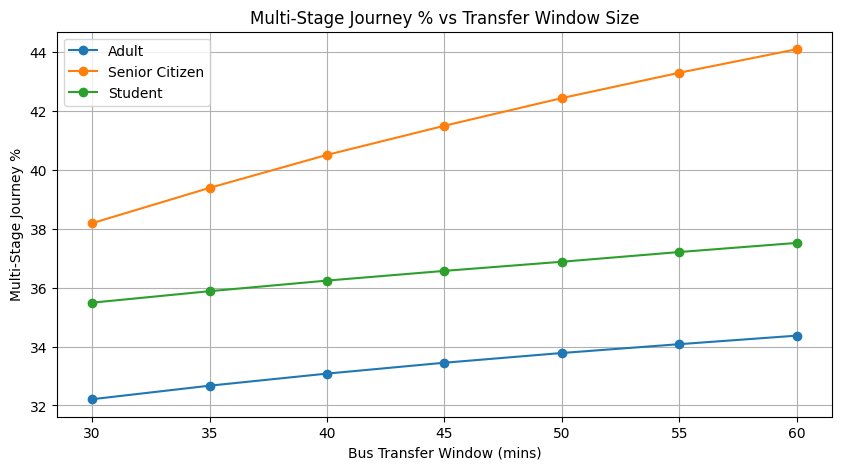

In [ ]:
'''# quick visualisation — multi_stage_% across window sizes per patron cat
patrons = ['Adult', 'Senior Citizen', 'Student']
windows = list(results.keys())

plt.figure(figsize=(10, 5))
for patron in patrons:
    pct = [results[w].loc[patron, 'multi_stage_%'] for w in windows]
    plt.plot(windows, pct, marker='o', label=patron)

plt.xlabel('Bus Transfer Window (mins)')
plt.ylabel('Multi-Stage Journey %')
plt.title('Multi-Stage Journey % vs Transfer Window Size')
plt.legend()
plt.grid(True)
plt.show()'''

## Ignore below because I used our classifier first then transfer window lol

Some Notes: 

- final flag from our classifier model is `final_termination_flag_spatial`. This marks the LAST RIDE of that journey. Every row belonging to the same joruney shares the same `final_journey_seq` number.
- in the below cost/benefit analysis
    - `multi_stage_journeys` = multiple rides classified into 1 journey. this is a journey count, not a ride count. UGWIM??
    - `single_stage_journeys` = only 1 ride in this journey

### Current classifier with no fixed transfer window

In [ ]:
'''# Our current classifier model, with no fixed transfer window allocated
# count stages per journey per commuter
journey_stage_counts = (
    df4.groupby(['CRD_NUM', 'final_journey_seq', 'PATRON_CATG_DESC_TXT']) # counts how many rides in a single journey
       .size()
       .reset_index(name='stage_count')
)

journey_stage_counts['is_single_stage'] = journey_stage_counts['stage_count'] == 1

# summary by patron category
summary = (
    journey_stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                        .size()
                        .unstack(fill_value=0)
                        .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
)
summary['total_journeys'] = summary['single_stage_journeys'] + summary['multi_stage_journeys']
summary['multi_stage_%'] = (summary['multi_stage_journeys'] / summary['total_journeys'] * 100).round(2)

print(summary)'''

is_single_stage       multi_stage_journeys  single_stage_journeys  \
PATRON_CATG_DESC_TXT                                                
Adult                              1064242                3041842   
Senior Citizen                      240716                 740830   
Student                             171499                 461883   

is_single_stage       total_journeys  multi_stage_%  
PATRON_CATG_DESC_TXT                                 
Adult                        4106084          25.92  
Senior Citizen                981546          24.52  
Student                       633382          27.08  


### Classifier with 45 minute transfer window imposed

In [ ]:
'''# impose 45-min hard cap on top of existing classifier
df4['w45_flag'] = (
    df4['final_termination_flag_spatial'] |
    (df4['time_gap_mins'] > 45)
)
# recompute journey sequence with 45-min window
df4['w45_journey_seq'] = (
    df4.groupby('CRD_NUM')['w45_flag']
       .shift(fill_value=False)
       .groupby(df4['CRD_NUM'])
       .cumsum()
)'''

In [ ]:
'''# count stages per journey
w45_stage_counts = (
    df4.groupby(['CRD_NUM', 'w45_journey_seq', 'PATRON_CATG_DESC_TXT'])
       .size()
       .reset_index(name='stage_count')
)

w45_stage_counts['is_single_stage'] = w45_stage_counts['stage_count'] == 1

w45_summary = (
    w45_stage_counts.groupby(['PATRON_CATG_DESC_TXT', 'is_single_stage'])
                    .size()
                    .unstack(fill_value=0)
                    .rename(columns={True: 'single_stage_journeys', False: 'multi_stage_journeys'})
)
w45_summary['total_journeys'] = w45_summary['single_stage_journeys'] + w45_summary['multi_stage_journeys']
w45_summary['multi_stage_%'] = (w45_summary['multi_stage_journeys'] / w45_summary['total_journeys'] * 100).round(2)

print(w45_summary)'''

is_single_stage       multi_stage_journeys  single_stage_journeys  \
PATRON_CATG_DESC_TXT                                                
Adult                              1064242                3041842   
Senior Citizen                      240716                 740830   
Student                             171499                 461883   

is_single_stage       total_journeys  multi_stage_%  
PATRON_CATG_DESC_TXT                                 
Adult                        4106084          25.92  
Senior Citizen                981546          24.52  
Student                       633382          27.08  


#### How did the additional 45min transfer window affect the classifier?

In [ ]:
'''# how many rows would the 45min window catch that the existing classifier doesn't?
new_flags = (
    (df4['final_termination_flag_spatial'] == False) &
    (df4['time_gap_mins'] > 45)
)
print(new_flags.sum())
# Gives 0! current classifier is already stricter than a 45-min window!'''

0


In [ ]:
'''# among rows classifier says are transfers, what's the time_gap distribution?
transfers = df4[df4['final_termination_flag_spatial'] == False]
print(transfers['time_gap_mins'].describe())
print(f"\n% with time_gap > 30: {(transfers['time_gap_mins'] > 30).mean()*100:.2f}%")
print(f"% with time_gap > 45: {(transfers['time_gap_mins'] > 45).mean()*100:.2f}%")
print(f"% with time_gap > 60: {(transfers['time_gap_mins'] > 60).mean()*100:.2f}%")'''

count    1.718541e+06
mean     5.787921e+00
std      4.991546e+00
min     -1.760000e+01
25%      2.250000e+00
50%      3.950000e+00
75%      7.800000e+00
max      3.598333e+01
Name: time_gap_mins, dtype: float64

% with time_gap > 30: 0.02%
% with time_gap > 45: 0.00%
% with time_gap > 60: 0.00%


Implement the 45-minute Window on our Current Classifier

Adjust the window and Observe Increases and Decreases across Different Patron Categories (maybe regions too?)
- Varying the Transfer Window in 5-minute Increments within a Range (e.g., 30 to 60 minutes)
- For each Increment, Consecutive Journey Stages are Reclassified under the Revised Transfer Window

Benefit: 
- Number of Additional Legitimate Journeys that become Eligible for a Single-Journey Fare under an Updated Longer Transfer Window
- MB: Increase in Number and Proportion of Legitimate Multi-Leg Journeys that Newly Qualify for a Single-Journey Fare when the Window is Increased (e.g., in 5-minute increments)


Cost: 
- Number of Distinct Standalone Journeys that may be Incorrectly Merged into a Single Transfer-Linked Journey under the Extended Window, Resulting in Potential Fare Undercharging
- Calculate the Fare Loss (in LTA’s point of view) from Journeys that are Incorrectly Merged